In [8]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from shapely import wkt
import altair as alt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import shutil
import subprocess
import os
import folium
import folium.plugins
import datetime
alt.data_transformers.disable_max_rows()
import warnings
warnings.filterwarnings("ignore")



os.environ["JAVA_HOME"] = subprocess.run(
    ["/usr/libexec/java_home", "-v", "21"],
    capture_output=True, text=True, check=True
).stdout.strip()


from r5py.util.config import Config
import r5py

Number of intersections:  166596
Number of road segments: 509190


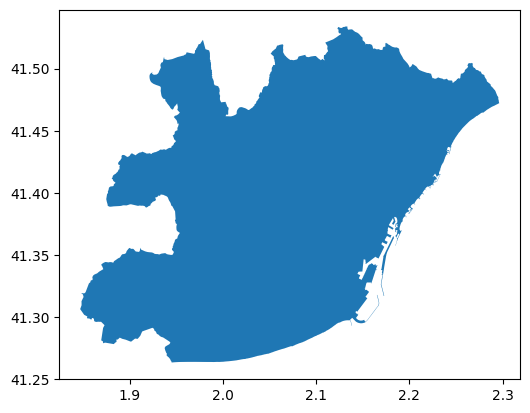

In [9]:
# Importing osmnx

# Define the polygon for the 1st district of Budapest
admin_district = ox.geocode_to_gdf('Àrea Metropolitana de Barcelona, Spain')
admin_district.plot()
admin_poly = admin_district.geometry.values[0]

# Load the graph from OSMnx
G = ox.graph_from_polygon(admin_poly, network_type='walk')

print('Number of intersections: ', G.number_of_nodes())
print('Number of road segments:',  G.number_of_edges())

In [10]:
neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)
neigh = neigh[["name", "geometry"]]
neigh["geometry"] = neigh.buffer(0)


neigh_layer = alt.Chart(neigh).mark_geoshape(
    stroke="black",
    fill="lightblue"
).properties(
    width=600,
    height=600
    
).encode(tooltip=['name'])

In [11]:
bus_sol = pd.read_csv('Nodes/Bus-Sol.csv')
bus = pd.read_csv('Nodes/Bus.csv')
fgc_sol = pd.read_csv('Nodes/FGC-Sol.csv')
fgc = pd.read_csv('Nodes/FGC.csv')
metro_sol = pd.read_csv('Nodes/Metro-Sol.csv')
metro = pd.read_csv('Nodes/Metro.csv')
tram_sol = pd.read_csv('Nodes/Tram-Sol.csv')
tram = pd.read_csv('Nodes/Tram.csv')
destinations = pd.read_csv('Nodes/Destinations.csv')

all_stops = pd.concat([bus_sol, bus, fgc_sol, fgc, metro_sol, metro, tram_sol, tram], ignore_index=True)
all_stops['geometry']= all_stops['geometry'].apply(wkt.loads)
all_stops = gpd.GeoDataFrame(all_stops, geometry='geometry', crs="EPSG:4326")
#all_stops = all_stops[:100]


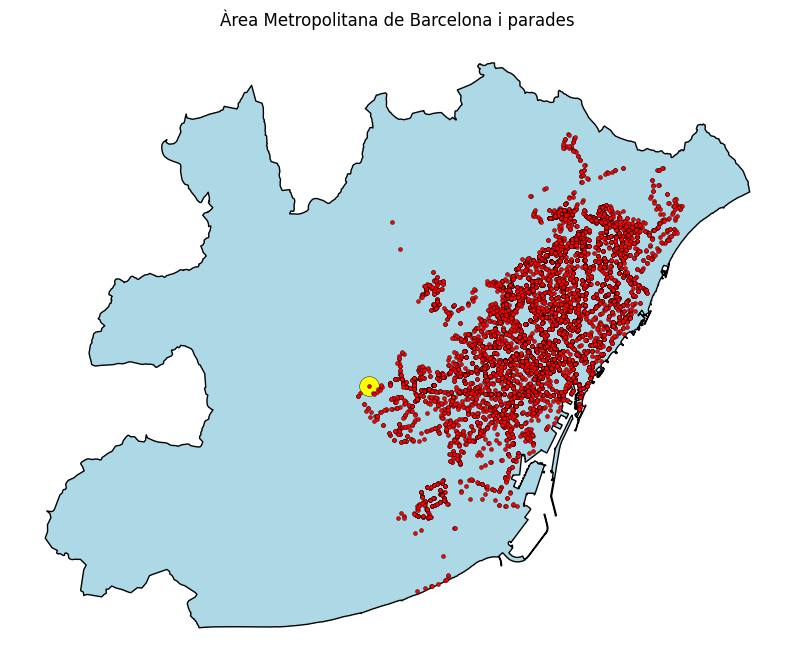

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

admin_district.plot(
    ax=ax,
    color="lightblue",
    edgecolor="black",
    linewidth=1
)

all_stops[all_stops['stop_id'] == 'CCML'].plot(
    ax=ax,
    color="yellow",
    markersize=200,
    edgecolor="black",
    linewidth=0.3
)

all_stops.plot(
    ax=ax,
    color="red",
    markersize=8,
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("Àrea Metropolitana de Barcelona i parades")
ax.axis("off")
plt.show()

In [13]:
all_stops[all_stops['stop_id'] == 'CCML']

,id,stop_id,name,linia,stop_type,geometry
6824,T-T3-CCML,CCML,Sant Feliu | Consell Comarcal,T3,Tram,POINT (2.05337 41.37936)


In [14]:
walking_speed = 1.39

for u, v, data in G.edges(data=True):
    data["travel_time"] = data["length"] / walking_speed


isochrone_time = 5
isochrone_polys = []

process = 1
for stop in all_stops['stop_id'].unique():
    print(f"Processing stop {stop} ({process}/{len(all_stops['stop_id'].unique())})")

    process += 1
    p = all_stops[all_stops['stop_id'] == stop].iloc[0]
    center_node = ox.distance.nearest_nodes(G, X=p['geometry'].x, Y=p["geometry"].y)

    subgraph = nx.ego_graph(
            G,
            center_node,
            radius= isochrone_time * 60,
            distance="travel_time"
        )

    node_points = [
        Point((data["x"], data["y"]))
        for node, data in subgraph.nodes(data=True)
    ]

    center_point = Point(G.nodes[center_node]["x"], G.nodes[center_node]["y"])

    polygon = gpd.GeoSeries(node_points).union_all().convex_hull
    isochrone_polys.append(
            gpd.GeoDataFrame(
                {"stop_id": [p["stop_id"]], "geometry": [polygon]},
                crs="EPSG:4326"
            )
        )

isochrone_polys = gpd.GeoDataFrame(pd.concat(isochrone_polys, ignore_index=True), crs="EPSG:4326")

Processing stop 2 (1/3267)
Processing stop 3 (2/3267)
Processing stop 7 (3/3267)
Processing stop 8 (4/3267)
Processing stop 13 (5/3267)
Processing stop 20 (6/3267)
Processing stop 21 (7/3267)
Processing stop 22 (8/3267)
Processing stop 24 (9/3267)
Processing stop 25 (10/3267)
Processing stop 31 (11/3267)
Processing stop 32 (12/3267)
Processing stop 34 (13/3267)
Processing stop 38 (14/3267)
Processing stop 39 (15/3267)
Processing stop 41 (16/3267)
Processing stop 42 (17/3267)
Processing stop 43 (18/3267)
Processing stop 44 (19/3267)
Processing stop 48 (20/3267)
Processing stop 51 (21/3267)
Processing stop 55 (22/3267)
Processing stop 58 (23/3267)
Processing stop 60 (24/3267)
Processing stop 63 (25/3267)
Processing stop 65 (26/3267)
Processing stop 69 (27/3267)
Processing stop 82 (28/3267)
Processing stop 94 (29/3267)
Processing stop 95 (30/3267)
Processing stop 98 (31/3267)
Processing stop 103 (32/3267)
Processing stop 105 (33/3267)
Processing stop 106 (34/3267)
Processing stop 108 (35/

In [15]:
isocores_df_all = all_stops[all_stops['stop_id'].isin(isochrone_polys['stop_id'].unique())].merge(isochrone_polys, on='stop_id', how='left')
isocores_df_all.drop(columns=['geometry_x'], inplace=True)
isocores_df_all.rename(columns={'geometry_y': 'geometry'}, inplace=True)
isocores_df_all.set_geometry('geometry', inplace=True)
isocores_df_all

,id,stop_id,name,linia,stop_type,geometry
0,SB-2,2,Av Icària - Àlaba,IU Stop,Bus,"POLYGON ((2.19864 41.39029, 2.19655 41.39061, ..."
1,SB-3,3,València - Muntaner,IU Stop,Bus,"POLYGON ((2.15827 41.38549, 2.15633 41.38565, ..."
2,SB-7,7,Pl Universitat,IU Stop,Bus,"POLYGON ((2.16361 41.38233, 2.15976 41.38319, ..."
3,SB-8,8,Pl de Carles Buïgas,IU Stop,Bus,"POLYGON ((2.15159 41.36902, 2.14665 41.36923, ..."
4,SB-13,13,Sas - Claramunt,IU Stop,Bus,"POLYGON ((2.20584 41.4342, 2.20432 41.43434, 2..."
...,...,...,...,...,...,...
6841,T-T5-STJB,STJB,Sant Joan Baptista,T5,Tram,"POLYGON ((2.22446 41.42451, 2.22411 41.42458, ..."
6842,T-T5-NKNS,NKNS,Encants de Sant Adrià,T5,Tram,"POLYGON ((2.21987 41.42728, 2.21921 41.42804, ..."
6843,T-T5-STRC,STRC,Sant Roc,T5,Tram,"POLYGON ((2.22644 41.43243, 2.22467 41.43269, ..."
6844,T-T5-GORG,GORG,Gorg,T5,Tram,"POLYGON ((2.23004 41.43745, 2.22926 41.43984, ..."


In [16]:
test = all_stops.copy()
isocores_df_all_merge = isocores_df_all.copy()
test.to_crs('EPSG:25831', inplace=True)
isocores_df_all_merge.to_crs('EPSG:25831', inplace=True)
test.rename(columns={'id': 'destination_id','stop_id':'destination_stop_id','name':'destination_stop_name','linia':'destination_linia','stop_type':'destination_stop_type'}, inplace=True)
isocores_df_all_merge.rename(columns={'id': 'origin_id','stop_id':'origin_stop_id','name':'origin_stop_name','linia':'origin_linia','stop_type':'origin_stop_type'}, inplace=True)
close_stops = gpd.sjoin(test[test['destination_id'].isin(isocores_df_all_merge['origin_id'])], isocores_df_all_merge, how='inner', predicate='within')
close_stops = close_stops[close_stops['origin_id'] != close_stops['destination_id']]
close_stops = close_stops[~close_stops['destination_id'].str.startswith('S')]
close_stops = close_stops[['origin_id', 'origin_stop_id', 'origin_stop_type', 'origin_stop_name', 'origin_linia', 'destination_id', 'destination_stop_id', 'destination_stop_type', 'destination_stop_name', 'destination_linia']]
close_stops['tram'] = close_stops['origin_stop_name'] + ' - ' + close_stops['destination_stop_name']
close_stops['mode'] = close_stops['origin_stop_type'] + ' - ' + close_stops['destination_stop_type']
close_stops['lines'] = close_stops['origin_linia'] + ' - ' + close_stops['destination_linia']
close_stops.drop(columns=['origin_stop_name', 'destination_stop_name','origin_linia','destination_linia'], inplace=True)
close_stops

,origin_id,origin_stop_id,origin_stop_type,destination_id,destination_stop_id,destination_stop_type,tram,mode,lines
812,SB-2,2,Bus,B-59-2,2,Bus,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
812,SB-34,34,Bus,B-59-2,2,Bus,Av Icària - Av Bogatell - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
812,SB-342,342,Bus,B-59-2,2,Bus,Cementiri de l'Est - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
812,SB-698,698,Bus,B-59-2,2,Bus,Av Icària - Joan Miró - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
812,B-H16-2,2,Bus,B-59-2,2,Bus,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,H16 - 59
...,...,...,...,...,...,...,...,...,...
6845,B-V33-3596,3596,Bus,T-T6-MINA,MINA,Tram,La Mina - Ponent - La Mina,Bus - Tram,V33 - T6
6845,B-B23-105999,105999,Bus,T-T6-MINA,MINA,Tram,Rambla de la Mina - La Mina,Bus - Tram,B23 - T6
6845,B-B23-106000,106000,Bus,T-T6-MINA,MINA,Tram,CAP La Mina - La Mina,Bus - Tram,B23 - T6
6845,T-T5-PARC,PARC,Tram,T-T6-MINA,MINA,Tram,Parc del Besòs - La Mina,Tram - Tram,T5 - T6


In [17]:
same_stops = close_stops[
    (close_stops['origin_stop_id'] == close_stops['destination_stop_id']) & (close_stops['origin_stop_type'] == close_stops['destination_stop_type'])
].copy()
same_stops = same_stops.drop(columns=['origin_stop_id', 'destination_stop_id'])

conditions = [
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith(('M', 'F'), na=False),
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith('B', na=False),
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith('T', na=False),
    same_stops['origin_id'].str.startswith('B', na=False) & same_stops['destination_id'].str.startswith('B', na=False),
    same_stops['origin_id'].str.startswith(('M', 'F'), na=False) & same_stops['destination_id'].str.startswith(('M', 'F'), na=False),
    same_stops['origin_id'].str.startswith('T', na=False) & same_stops['destination_id'].str.startswith('T', na=False),

]
choices = [3, 1, 2, 1, 2, 1]
same_stops['type'] = 'Exchange - Self'
same_stops['time'] = np.select(conditions, choices, default=0)
# same_stops['time'] = pd.to_timedelta(
#     np.select(conditions, choices, default=0),
#     unit='m'
# )

# same_stops['time'] = same_stops['time'].apply(
#     lambda x: f"{int(x.total_seconds() // 60):02d}:{int(x.total_seconds() % 60):02d}"
# )
same_stops['geometry'] = same_stops.apply(lambda row: all_stops.loc[all_stops['id'] == row['origin_id'], 'geometry'].values[0], axis=1)
same_stops.drop(columns=['origin_stop_type', 'destination_stop_type'], inplace=True)
same_stops


,origin_id,destination_id,tram,mode,lines,type,time,geometry
812,SB-2,B-59-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,IU Stop - 59,Exchange - Self,1,POINT (2.198984998801282 41.393104003754864)
812,B-H16-2,B-59-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,H16 - 59,Exchange - Self,1,POINT (2.198984998801282 41.393104003754864)
812,B-V27-2,B-59-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,V27 - 59,Exchange - Self,1,POINT (2.198984998801282 41.393104003754864)
813,SB-2,B-H16-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,IU Stop - H16,Exchange - Self,1,POINT (2.198984998801282 41.393104003754864)
813,B-59-2,B-H16-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,59 - H16,Exchange - Self,1,POINT (2.198984998801282 41.393104003754864)
...,...,...,...,...,...,...,...,...
6836,T-T6-ALFS,T-T5-ALFS,Alfons el Magnànim - Alfons el Magnànim,Tram - Tram,T6 - T5,Exchange - Self,1,POINT (2.213568925857544 41.41719055175781)
6837,ST-ALFS,T-T6-ALFS,Alfons el Magnànim - Alfons el Magnànim,Tram - Tram,IU Stop - T6,Exchange - Self,2,POINT (2.213568925857544 41.41719055175781)
6837,T-T5-ALFS,T-T6-ALFS,Alfons el Magnànim - Alfons el Magnànim,Tram - Tram,T5 - T6,Exchange - Self,1,POINT (2.213568925857544 41.41719055175781)
6838,T-T6-PARC,T-T5-PARC,Parc del Besòs - Parc del Besòs,Tram - Tram,T6 - T5,Exchange - Self,1,POINT (2.217633008956909 41.419429779052734)


In [18]:
# cache_dir = Config().CACHE_DIR
# for f in cache_dir.glob("*.mapdb*"):
#     f.unlink()

In [19]:
transport_network = r5py.TransportNetwork(
    "Data/Neigh/cataluna-260811.osm.pbf",
    elevation_model =["Data/Neigh/elevacions-terreny-lidar-Catalunya-2m-2008-2011tif1786456535055.tif"]
    )

In [20]:
itineraries = pd.DataFrame()
process = 0
failed_iteraries = []
different_stops = close_stops[
    (close_stops['origin_stop_id'] != close_stops['destination_stop_id'])
]


for stop in different_stops['origin_stop_id'].unique():
    process += 1
    print(f"Processing {process}/{different_stops['origin_stop_id'].nunique()}")
    stops = different_stops[different_stops['origin_stop_id'] == stop]
    stops.drop_duplicates(subset=['origin_stop_id', 'destination_stop_id'], inplace=True)

    for _, row in stops.iterrows():
        origin_id = row['origin_stop_id']
        destination_id = row['destination_stop_id']

        # if origin_id  != 1323:
        #     continue
        # if destination_id != 2:
        #     continue

        # if process != 2374:
        #     continue

        origins = all_stops[all_stops['stop_id'] == origin_id].copy()
        origins.drop_duplicates(subset=['stop_id'], inplace=True)
        destinations = all_stops[all_stops['stop_id'] == destination_id].copy()
        destinations.drop_duplicates(subset=['stop_id'], inplace=True)
        origins.rename(columns={'origin_id': 'id'}, inplace=True)
        destinations.rename(columns={'destination_id': 'id'}, inplace=True)
        origins = gpd.GeoDataFrame(origins, geometry='geometry', crs="EPSG:4326")
        destinations = gpd.GeoDataFrame(destinations, geometry='geometry', crs="EPSG:4326")
        detailed_itineraries = r5py.DetailedItineraries(
            transport_network,
            origins=origins,
            destinations=destinations,
            transport_modes=[r5py.TransportMode.WALK],
            snap_to_network=True,
            speed_walking = 5,
            departure=datetime.datetime(2026, 5, 13, 9, 30),

        )

        if len(detailed_itineraries) == 0:
            failed_iteraries.append((origin_id, destination_id))
            continue
        exchange_time = detailed_itineraries['travel_time'].sum()
        itineraries_row = pd.DataFrame({
            'origin_stop_id': [origin_id],
            'destination_stop_id': [destination_id],
            'time': [exchange_time],
            'geometry': [detailed_itineraries['geometry'].iloc[0]],
        })

        itineraries_row = gpd.GeoDataFrame(itineraries_row, geometry='geometry', crs="EPSG:4326")
        itineraries = pd.concat([itineraries, itineraries_row], ignore_index=True)


itineraries["time"] = itineraries["time"].apply(
    lambda x: x.total_seconds() / 60
)


Processing 1/3211
Processing 2/3211
Processing 3/3211
Processing 4/3211
Processing 5/3211
Processing 6/3211
Processing 7/3211
Processing 8/3211
Processing 9/3211
Processing 10/3211
Processing 11/3211
Processing 12/3211
Processing 13/3211
Processing 14/3211
Processing 15/3211
Processing 16/3211
Processing 17/3211
Processing 18/3211
Processing 19/3211
Processing 20/3211
Processing 21/3211
Processing 22/3211
Processing 23/3211
Processing 24/3211
Processing 25/3211
Processing 26/3211
Processing 27/3211
Processing 28/3211
Processing 29/3211
Processing 30/3211
Processing 31/3211
Processing 32/3211
Processing 33/3211
Processing 34/3211
Processing 35/3211
Processing 36/3211
Processing 37/3211
Processing 38/3211
Processing 39/3211
Processing 40/3211
Processing 41/3211
Processing 42/3211
Processing 43/3211
Processing 44/3211
Processing 45/3211
Processing 46/3211
Processing 47/3211
Processing 48/3211
Processing 49/3211
Processing 50/3211
Processing 51/3211
Processing 52/3211
Processing 53/3211
Pr

In [21]:
different_stops_final = different_stops.merge(itineraries, on=['origin_stop_id', 'destination_stop_id'], how='left')
different_stops_final.drop(columns=['origin_stop_id', 'destination_stop_id','destination_stop_type','origin_stop_type'], inplace=True)
different_stops_final.insert(5, 'type', 'Exchange')
different_stops_final = different_stops_final[different_stops_final['geometry'].notnull()]

In [22]:
all_exchanges = pd.concat([same_stops, different_stops_final], ignore_index=True)
all_exchanges.rename(columns={'origin_id': 'origen', 'destination_id': 'dest','exchange_time':'time'}, inplace=True)
#all_exchanges = gpd.GeoDataFrame(all_exchanges, geometry='geometry', crs="EPSG:4326")
all_exchanges = all_exchanges[all_exchanges['time'] <= 5]
all_exchanges.insert(7, 'directed', True)

In [24]:
all_exchanges.to_csv('Edges/Exchanges.csv', index=False)

In [ ]:
# Frame 1: polygons only
isochrone_chart = alt.Chart(isocores_df_all[isocores_df_all['stop_id'].isin([2575])]).mark_geoshape(
    stroke='black',
    strokeWidth=1
).encode(tooltip=['id'])

points = alt.Chart(all_stops[all_stops['stop_id'].isin([2575,84])]).mark_geoshape(
    fill='red',
    stroke='black',
    strokeWidth=1,
    size=0
).encode(
    tooltip=['name']
)

itineraries_chart = alt.Chart(all_exchanges[all_exchanges['origen'].isin(['B-B80-2575']) & (all_exchanges['dest'].isin(['B-B18-84']))]).mark_geoshape(
    filled = False,
    stroke='black',
    strokeWidth=1,
    size=0
)


(
isochrone_chart + points + itineraries_chart  ).properties(
    width=900,
    height=900
)

In [ ]:
# Frame 1: polygons only
polys_df = isocores_df_all[['id', 'geometry']].copy()
polys_df = gpd.GeoDataFrame(polys_df, geometry='geometry', crs="EPSG:4326")


not_self_exchanges = all_exchanges[all_exchanges['type'] == 'Exchange'].copy()
#not_self_exchanges = not_self_exchanges[not_self_exchanges['mode'] == 'Bus - Tram']
origens = not_self_exchanges['origen'].unique().tolist()
destinations = not_self_exchanges['dest'].unique().tolist()
stops =  origens + destinations

isochrone_chart = alt.Chart(polys_df[polys_df['id'].isin(origens)]).mark_geoshape(
    stroke='black',
    strokeWidth=1
).encode(tooltip=['id'])

points = alt.Chart(all_stops[all_stops['id'].isin(stops)]).mark_geoshape(
    fill='red',
    stroke='black',
    strokeWidth=1,
    size=0
).encode(
    tooltip=['name']
)

itineraries_chart = alt.Chart(not_self_exchanges).mark_geoshape(
    filled = False,
    stroke='black',
    strokeWidth=1,
    size=0
)


(
neigh_layer + isochrone_chart).properties(
    width=900,
    height=900
)

In [ ]:



# ---------------------------------------------------------
# Load neighbourhoods
# ---------------------------------------------------------

neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)

neigh = neigh[["name", "geometry"]]

neigh["geometry"] = neigh.geometry.buffer(0)


# ---------------------------------------------------------
# Prepare itinerary data
# ---------------------------------------------------------

itineraries["mode"] = itineraries["transport_mode"].astype(str)

itineraries["travel time (min)"] = itineraries["travel_time"].apply(
    lambda t: round(t.total_seconds() / 60.0, 2)
)

itineraries["trip"] = itineraries.apply(
    lambda row: f"{row['from_id']} → {row['to_id']}",
    axis=1
)


# ---------------------------------------------------------
# Create map
# ---------------------------------------------------------



detailed_routes_map = (
    itineraries[
        [
            "geometry",
            "distance",
            "mode",
            "travel time (min)",
            "from_id",
            "to_id",
            "trip",
            "option",
            "segment",
        ]
    ]
    .explore(
        tooltip=[
            "trip",
            "option",
            "segment",
            "mode",
            "travel time (min)",
            "distance",
        ],
        column="mode",
        tiles="CartoDB.Positron",
        style_kwds={
            "weight": 3,
            "opacity": 0.8,
        },
        highlight_kwds={
            "weight": 6,
            "opacity": 1,
        },
    )
)


isochrone_polys.explore(
    m=detailed_routes_map,
    tooltip=["stop_id"],
    style_kwds={
        "fillOpacity": 0.15,
        "weight": 1,
    },
)

# ---------------------------------------------------------
# Get stops involved in the itineraries
# ---------------------------------------------------------

stop_ids = pd.unique(
    pd.concat([
        itineraries["from_id"],
        itineraries["to_id"]
    ])
)

stops_map = all_stops[
    all_stops["id"].isin(stop_ids)
].copy()

stops_map = gpd.GeoDataFrame(
    stops_map,
    geometry="geometry",
    crs="EPSG:4326"
)


# ---------------------------------------------------------
# Assign neighbourhood to each stop
# ---------------------------------------------------------

# Project both layers for the spatial join
stops_projected = stops_map.to_crs("EPSG:25831")
neigh_projected = neigh.to_crs("EPSG:25831")

stops_map = gpd.sjoin(
    stops_projected,
    neigh_projected[["name", "geometry"]],
    how="left",
    predicate="within"
)

# Return to WGS84 for Folium
stops_map = stops_map.to_crs("EPSG:4326")


# ---------------------------------------------------------
# Add stop markers
# ---------------------------------------------------------

stops_map.apply(
    lambda row: folium.Marker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        tooltip=(
            f"Stop: {row['id']}<br>"
        ),
        icon=folium.plugins.BeautifyIcon(
            icon_shape="marker",
            number=str(row["id"]),
            border_color="#728224",
            text_color="#728224",
        ),
    ).add_to(detailed_routes_map),
    axis=1,
)


detailed_routes_map